# Choix final — maximiser la détection des défauts sur `wood`

## Décision métier

> **Il vaut mieux provoquer trop d'inspections que de laisser passer trop de défauts.**

Concrètement : le coût d'un défaut manqué (panne, rebut en aval, incident) est jugé bien supérieur au
coût d'une inspection manuelle inutile déclenchée par une fausse alerte. Ce notebook en tire les
conséquences techniques : **choisir, entre les modèles déjà entraînés dans ce projet, celui qui
maximise le rappel**, puis **calibrer son seuil de décision pour rater le moins de défauts possible**,
quitte à accepter davantage de fausses alertes que dans les choix précédents (`02c`, `02e`,
`tp_deep_learning`, qui visaient un compromis plus équilibré).

## Ce que ce notebook fait, et ne fait pas

- Il **réentraîne** les deux candidats déjà comparés dans
  [`tp_deep_learning.ipynb`](tp_deep_learning.ipynb) sur la catégorie `wood` : l'**auto-encodeur**
  convolutif (baseline pédagogique de la consigne) et **PatchCore** (bibliothèque `anomalib`, déjà
  identifié comme nettement supérieur).
- Il **balaye** un plus grand nombre de politiques de seuil que `02e` (qui n'en testait que 7 sur
  l'auto-encodeur) pour les deux modèles, **calibrées uniquement sur la validation saine** — jamais sur
  le test, pour ne pas biaiser le choix.
- Il **retient une politique** par un critère explicite et fixé à l'avance (détaillé en étape 4), pas en
  cherchant après coup le meilleur chiffre sur le test.
- Il ne ré-explore ni le goulot resserré, ni la perte SSIM, ni la catégorie `metal_nut` (déjà traités
  dans `tp_deep_learning.ipynb`) : seule la question du **seuil**, à modèle fixé, change ici.

## Prérequis

- **Noyau Jupyter** : `Python 3.12 (indusense, PyTorch ROCm)` (`indusense-py312-rocm`).
- Ouvrir depuis la racine du projet `indusense`.
- Bibliothèque `anomalib` installée (voir `tp_deep_learning.ipynb`, section PatchCore).

In [1]:
from pathlib import Path
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch

PROJECT_ROOT = Path.cwd()
assert (PROJECT_ROOT / 'pyproject.toml').exists(), (
    'Ouvrir le notebook depuis la racine du projet indusense.'
)

DEVICE = "cuda"
assert torch.cuda.is_available(), "GPU ROCm non détecté par PyTorch."
device = torch.device(DEVICE)
print(f'PyTorch {torch.__version__}, device={device} ({torch.cuda.get_device_name(0)})')

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)
import tqdm.std
_original_tqdm_init = tqdm.std.tqdm.__init__
def _silent_tqdm_init(self, *args, **kwargs):
    kwargs['disable'] = True
    _original_tqdm_init(self, *args, **kwargs)
tqdm.std.tqdm.__init__ = _silent_tqdm_init

from indusense.vision.dataset import (
    list_defect_categories, list_image_paths, list_mask_paths, load_image_batch, load_mask_batch,
    resolve_category_root, split_train_validation,
)
from indusense.vision.augment import augment_batch, build_augmentation_pipeline
from indusense.vision.autoencoder_torch import (
    ConvAutoencoder, count_trainable_parameters, images_to_tensor, tensor_to_images,
)
from indusense.vision.anomaly import (
    choose_threshold, choose_threshold_percentile, evaluate_at_threshold, ranking_metrics,
    reconstruction_error,
)

CATEGORY = 'wood'
IMAGE_SIZE = 256
BASE_CHANNELS = 64
KERNEL_SIZE = 3
BATCH_SIZE = 32
EPOCHS = 60
VALIDATION_FRACTION = 0.15
SEED = 42

category_root = resolve_category_root(CATEGORY)
defect_categories = list_defect_categories(category_root)
train_good_paths = list_image_paths(category_root, 'train', 'good')
split = split_train_validation(train_good_paths, validation_fraction=VALIDATION_FRACTION, seed=SEED)

test_good_paths = list_image_paths(category_root, 'test', 'good')
test_defect_paths = {d: list_image_paths(category_root, 'test', d) for d in defect_categories}

train_raw_images = load_image_batch(split.train_paths, IMAGE_SIZE)
validation_images = load_image_batch(split.validation_paths, IMAGE_SIZE)
test_good_images = load_image_batch(test_good_paths, IMAGE_SIZE)
test_defect_images = {d: load_image_batch(paths, IMAGE_SIZE) for d, paths in test_defect_paths.items()}
test_images_by_group = {'good': test_good_images, **test_defect_images}

test_labels = np.concatenate([
    np.zeros(len(test_good_images), dtype=int),
    *[np.ones(len(test_defect_images[d]), dtype=int) for d in defect_categories],
])

augmentation_pipeline = build_augmentation_pipeline(seed=SEED)

print(f'Train (saines, augmentées) : {len(split.train_paths)}')
print(f'Validation (saines, calibration du seuil) : {len(split.validation_paths)}')
print(f'Test sain : {len(test_good_images)} ; test défauts : {sum(len(v) for v in test_defect_images.values())} '
      f'({", ".join(defect_categories)})')

PyTorch 2.9.1+rocm7.2.1, device=cuda (AMD Radeon RX 9070 XT)


D:\source\A4U\FormationIA\indusense\.venv-py312-rocm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train (saines, augmentées) : 210
Validation (saines, calibration du seuil) : 37
Test sain : 19 ; test défauts : 60 (color, combined, hole, liquid, scratch)


## Étape 1 — Réentraîner les deux modèles candidats

Mêmes hyperparamètres, mêmes données, même seed que dans `tp_deep_learning.ipynb`, pour disposer de
modèles entraînés dans ce notebook autonome. Le suivi MLflow réutilise l'expérience déjà créée
(`indusense-autoencodeur-anomalies`).

In [2]:
import mlflow

MLFLOW_STORE = PROJECT_ROOT / '.mlflow'
MLFLOW_ARTIFACTS = MLFLOW_STORE / 'artifacts'
MLFLOW_EXPERIMENT = 'indusense-autoencodeur-anomalies'

mlflow.set_tracking_uri('sqlite:///' + (MLFLOW_STORE / 'mlflow.db').as_posix())
if mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT) is None:
    mlflow.create_experiment(MLFLOW_EXPERIMENT, artifact_location=MLFLOW_ARTIFACTS.as_uri())
mlflow.set_experiment(MLFLOW_EXPERIMENT)


def run_epoch(raw_images, model, optimizer, loss_fn, pipeline, device, batch_size):
    augmented = np.clip(augment_batch(raw_images, pipeline), 0.0, 1.0)
    batch = images_to_tensor(augmented).to(device)
    permutation = torch.randperm(batch.shape[0])
    running_loss = 0.0
    model.train()
    for start in range(0, batch.shape[0], batch_size):
        indices = permutation[start:start + batch_size]
        images = batch[indices]
        optimizer.zero_grad()
        reconstruction = model(images)
        loss = loss_fn(reconstruction, images)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.shape[0]
    return running_loss / batch.shape[0]


@torch.no_grad()
def reconstruct(images_hwc, model, device, batch_size=32):
    model.eval()
    tensor = images_to_tensor(images_hwc)
    outputs = []
    for start in range(0, tensor.shape[0], batch_size):
        batch = tensor[start:start + batch_size].to(device)
        outputs.append(tensor_to_images(model(batch)))
    return np.concatenate(outputs, axis=0)


torch.manual_seed(SEED)
ae_model = ConvAutoencoder(base_channels=BASE_CHANNELS, kernel_size=KERNEL_SIZE).to(device)
ae_parameters = count_trainable_parameters(ae_model)
optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

started = time.perf_counter()
with mlflow.start_run(run_name='final-choice-autoencoder-mse-bc64'):
    mlflow.log_params({
        'image_size': IMAGE_SIZE, 'batch_size': BATCH_SIZE, 'epochs': EPOCHS,
        'base_channels': BASE_CHANNELS, 'kernel_size': KERNEL_SIZE, 'loss': 'mse',
        'category': CATEGORY, 'trainable_parameters': ae_parameters,
    })
    for epoch in range(EPOCHS):
        train_loss = run_epoch(train_raw_images, ae_model, optimizer, loss_fn, augmentation_pipeline, device, BATCH_SIZE)
        if (epoch + 1) % 20 == 0 or epoch == EPOCHS - 1:
            print(f'Auto-encodeur — époque {epoch + 1:>3}/{EPOCHS} — perte MSE (train) = {train_loss:.5f}')
    ae_train_seconds = time.perf_counter() - started
    mlflow.log_metric('train_seconds', ae_train_seconds)

print(f'\nAuto-encodeur entraîné en {ae_train_seconds:.1f} s ({ae_parameters:,} paramètres)'.replace(',', ' '))

2026/09/22 12:04:00 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at D:\source\A4U\FormationIA\indusense\.venv-py312-rocm\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


Auto-encodeur — époque  20/60 — perte MSE (train) = 0.00106


Auto-encodeur — époque  40/60 — perte MSE (train) = 0.00052


Auto-encodeur — époque  60/60 — perte MSE (train) = 0.00033

Auto-encodeur entraîné en 48.4 s (741 379 paramètres)


In [3]:
from anomalib.models.image.patchcore.torch_model import PatchcoreModel

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)


def to_imagenet_tensor(images_hwc, batch_device):
    tensor = images_to_tensor(images_hwc).to(batch_device)
    return (tensor - IMAGENET_MEAN) / IMAGENET_STD


def train_patchcore(train_images_hwc, sampling_ratio=0.1, batch_size=16,
                     backbone='wide_resnet50_2', layers=('layer2', 'layer3'), num_neighbors=9):
    model = PatchcoreModel(
        layers=list(layers), backbone=backbone, pre_trained=True, num_neighbors=num_neighbors,
    ).to(device)
    model.train()
    with torch.no_grad():
        for start in range(0, len(train_images_hwc), batch_size):
            batch = to_imagenet_tensor(train_images_hwc[start:start + batch_size], device)
            model(batch)
    model.subsample_embedding(sampling_ratio=sampling_ratio)
    model.eval()
    return model


@torch.no_grad()
def patchcore_infer(model, images_hwc, batch_size=16):
    scores = []
    for start in range(0, len(images_hwc), batch_size):
        batch = to_imagenet_tensor(images_hwc[start:start + batch_size], device)
        output = model(batch)
        scores.append(output.pred_score.cpu().numpy())
    return np.concatenate(scores)


started = time.perf_counter()
with mlflow.start_run(run_name='final-choice-patchcore-wood'):
    mlflow.log_params({'category': CATEGORY, 'backbone': 'wide_resnet50_2', 'layers': 'layer2,layer3',
                       'sampling_ratio': 0.1, 'num_neighbors': 9})
    pc_model = train_patchcore(train_raw_images)
    pc_train_seconds = time.perf_counter() - started
    mlflow.log_metric('train_seconds', pc_train_seconds)

print(f'PatchCore entraîné (mémoire de patchs) en {pc_train_seconds:.1f} s')

PatchCore entraîné (mémoire de patchs) en 32.7 s


## Étape 2 — Calculer les scores d'anomalie (validation et test)

L'erreur de reconstruction (auto-encodeur) et la distance au plus proche voisin (PatchCore) sont
calculées une seule fois, sur la validation saine et sur tout le test — chaque politique de seuil
testée en étape 4 réutilise ensuite ces mêmes scores, sans jamais réévaluer les modèles.

In [4]:
ae_validation_scores = reconstruction_error(validation_images, reconstruct(validation_images, ae_model, device))
ae_test_scores_by_group = {
    group: reconstruction_error(images, reconstruct(images, ae_model, device))
    for group, images in test_images_by_group.items()
}
ae_test_scores = np.concatenate([ae_test_scores_by_group['good']] + [ae_test_scores_by_group[d] for d in defect_categories])

pc_validation_scores = patchcore_infer(pc_model, validation_images)
pc_test_scores_by_group = {group: patchcore_infer(pc_model, images) for group, images in test_images_by_group.items()}
pc_test_scores = np.concatenate([pc_test_scores_by_group['good']] + [pc_test_scores_by_group[d] for d in defect_categories])

ae_ranking = ranking_metrics(test_labels, ae_test_scores)
pc_ranking = ranking_metrics(test_labels, pc_test_scores)
print(f"Auto-encodeur — ROC-AUC : {ae_ranking['roc_auc']:.4f} ; PR-AUC : {ae_ranking['pr_auc']:.4f}")
print(f"PatchCore      — ROC-AUC : {pc_ranking['roc_auc']:.4f} ; PR-AUC : {pc_ranking['pr_auc']:.4f}")

Auto-encodeur — ROC-AUC : 0.9632 ; PR-AUC : 0.9884
PatchCore      — ROC-AUC : 0.9851 ; PR-AUC : 0.9956


## Étape 3 — Balayer un grand nombre de politiques de seuil

Pour chaque modèle, 13 politiques calibrées **uniquement sur la validation saine** (37 images) :
percentiles bas et hauts (`50` à `99`, plus permissifs que les seuils utilisés jusqu'ici dans ce
projet) et `moyenne + k·écart-type` pour `k` allant de `0,5` à `3`. Pour chaque politique, on calcule
le **taux de fausses alertes attendu sur la validation** (connu avant de regarder le test) et, à titre
d'évaluation, précision/rappel/F1 sur le test.

In [5]:
from tabulate import tabulate


def build_threshold_candidates(validation_scores):
    candidates = []
    for percentile in [50, 60, 70, 75, 80, 85, 90, 95, 97, 99]:
        candidates.append((f'percentile {percentile}', choose_threshold_percentile(validation_scores, percentile=percentile)))
    for k in [0.5, 1.0, 1.5, 2.0, 3.0]:
        candidates.append((f'moyenne + {k}σ', choose_threshold(validation_scores, n_std=k)))
    return candidates


def sweep_thresholds(validation_scores, test_scores):
    rows = []
    for name, threshold in build_threshold_candidates(validation_scores):
        fa_rate = float((validation_scores >= threshold).mean())
        metrics = evaluate_at_threshold(test_labels, test_scores, threshold)
        rows.append({
            'policy': name, 'threshold': threshold, 'fa_rate_validation': fa_rate,
            'precision': metrics.precision, 'recall': metrics.recall, 'f1': metrics.f1,
            'fp': metrics.false_positive, 'fn': metrics.false_negative,
        })
    return rows


ae_sweep = sweep_thresholds(ae_validation_scores, ae_test_scores)
pc_sweep = sweep_thresholds(pc_validation_scores, pc_test_scores)

for label, rows in [('Auto-encodeur', ae_sweep), ('PatchCore', pc_sweep)]:
    print(f'=== {label} ===')
    print(tabulate(
        [[r['policy'], f"{r['fa_rate_validation']:.1%}", f"{r['precision']:.3f}", f"{r['recall']:.3f}",
          f"{r['f1']:.3f}", r['fp'], r['fn']] for r in rows],
        headers=['Politique', 'FA validation', 'Précision (test)', 'Rappel (test)', 'F1 (test)', 'FP', 'FN'],
        tablefmt='github',
    ))
    print()

=== Auto-encodeur ===
| Politique      | FA validation   |   Précision (test) |   Rappel (test) |   F1 (test) |   FP |   FN |
|----------------|-----------------|--------------------|-----------------|-------------|------|------|
| percentile 50  | 51.4%           |               0.98 |           0.817 |       0.891 |    1 |   11 |
| percentile 60  | 40.5%           |               1    |           0.75  |       0.857 |    0 |   15 |
| percentile 70  | 29.7%           |               1    |           0.517 |       0.681 |    0 |   29 |
| percentile 75  | 27.0%           |               1    |           0.367 |       0.537 |    0 |   38 |
| percentile 80  | 21.6%           |               1    |           0.283 |       0.442 |    0 |   43 |
| percentile 85  | 16.2%           |               1    |           0.25  |       0.4   |    0 |   45 |
| percentile 90  | 10.8%           |               1    |           0.25  |       0.4   |    0 |   45 |
| percentile 95  | 5.4%            |      

## Lecture du résultat précédent : jusqu'où peut-on pousser le rappel ?

Deux comportements radicalement différents apparaissent.

**L'auto-encodeur plafonne, même au seuil le plus permissif testé.** À `percentile 50` (le seuil le plus bas testé — la moitié des images saines de validation dépassent déjà ce seuil), le rappel n'atteint que **0,817** (49 défauts détectés sur 60, 11 manqués) — pour un coût déjà énorme : **51,4 %** des pièces saines de validation seraient signalées. Rendre le seuil encore plus permissif ne changerait rien : les erreurs de reconstruction des 11 défauts les plus discrets (essentiellement `liquid`, déjà identifié dans `tp_deep_learning.ipynb` comme le défaut le plus proche du bruit de reconstruction des saines) sont **structurellement** trop proches de celles des images saines pour qu'un seuil, quel qu'il soit, les sépare. C'est une limite du **score** lui-même, pas de la politique de seuil.

**PatchCore atteint un rappel de 1,000 sur presque toute la plage testée.** Du `percentile 50` au `percentile 99`, et de `moyenne + 0,5σ` à `moyenne + 2σ`, le rappel reste à **1,000** (0 défaut manqué) — seule la politique la plus conservatrice (`moyenne + 3σ`) laisse passer 1 défaut sur 60. Le taux de fausses alertes nécessaire pour atteindre ce rappel parfait est beaucoup plus faible que pour l'auto-encodeur : dès `percentile 99` (2,7 % de fausses alertes sur la validation), le rappel est déjà de 1,000.

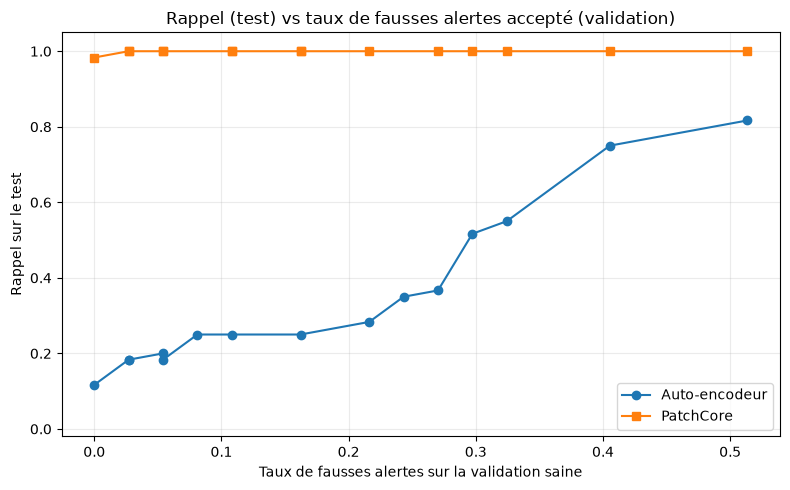

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, rows, marker in [('Auto-encodeur', ae_sweep, 'o'), ('PatchCore', pc_sweep, 's')]:
    fa = [r['fa_rate_validation'] for r in rows]
    recall = [r['recall'] for r in rows]
    order = np.argsort(fa)
    ax.plot(np.array(fa)[order], np.array(recall)[order], marker=marker, label=label)
ax.set(
    title="Rappel (test) vs taux de fausses alertes accepté (validation)",
    xlabel='Taux de fausses alertes sur la validation saine', ylabel='Rappel sur le test',
)
ax.set_ylim(-0.02, 1.05)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()

with mlflow.start_run(run_name='final-choice-comparison'):
    mlflow.log_figure(fig, 'recall_vs_fa_rate.png')
plt.show()

## Étape 4 — Choisir la politique finale (règle fixée avant de regarder le test)

Le choix du seuil ne doit **jamais** consister à chercher, après coup, la ligne du tableau ci-dessus qui
« gagne » sur le test — ce serait sur-ajuster la décision à 79 images de test, un biais déjà signalé
dans [`02e`](02e-autoencoder-pytorch-gpu-seuils.ipynb). La règle est fixée **avant** de lire les
résultats de test, directement à partir de la décision métier :

> **Retenir, parmi les politiques calibrées sur la validation, celle qui atteint le meilleur rappel ;
> en cas d'égalité, celle qui minimise le taux de fausses alertes** (inutile de provoquer plus
> d'inspections que ce que le rappel maximal exige).

Cette règle ne regarde le test qu'une fois appliquée, pour rapporter honnêtement le résultat — jamais
pour choisir entre plusieurs candidats a posteriori.

In [7]:
def pick_policy(rows):
    max_recall = max(r['recall'] for r in rows)
    tied = [r for r in rows if r['recall'] == max_recall]
    return min(tied, key=lambda r: r['fa_rate_validation'])


ae_choice = pick_policy(ae_sweep)
pc_choice = pick_policy(pc_sweep)

print('=== Politique retenue — Auto-encodeur ===')
print(tabulate([[ae_choice['policy'], f"{ae_choice['threshold']:.6f}", f"{ae_choice['fa_rate_validation']:.1%}",
                 f"{ae_choice['precision']:.3f}", f"{ae_choice['recall']:.3f}", ae_choice['fp'], ae_choice['fn']]],
                headers=['Politique', 'Seuil', 'FA validation', 'Précision', 'Rappel', 'FP', 'FN'], tablefmt='github'))

print('\n=== Politique retenue — PatchCore ===')
print(tabulate([[pc_choice['policy'], f"{pc_choice['threshold']:.6f}", f"{pc_choice['fa_rate_validation']:.1%}",
                 f"{pc_choice['precision']:.3f}", f"{pc_choice['recall']:.3f}", pc_choice['fp'], pc_choice['fn']]],
                headers=['Politique', 'Seuil', 'FA validation', 'Précision', 'Rappel', 'FP', 'FN'], tablefmt='github'))

=== Politique retenue — Auto-encodeur ===
| Politique     |    Seuil | FA validation   |   Précision |   Rappel |   FP |   FN |
|---------------|----------|-----------------|-------------|----------|------|------|
| percentile 50 | 0.000445 | 51.4%           |        0.98 |    0.817 |    1 |   11 |

=== Politique retenue — PatchCore ===
| Politique     |   Seuil | FA validation   |   Précision |   Rappel |   FP |   FN |
|---------------|---------|-----------------|-------------|----------|------|------|
| percentile 99 | 35.2605 | 2.7%            |       0.882 |        1 |    8 |    0 |


## Lecture du résultat précédent : quel modèle et quel seuil retenir pour la production ?

La règle fixée à l'avance (étape 4) sélectionne :

- **Auto-encodeur → `percentile 50`** : c'est la politique la plus permissive testée, et pourtant son rappel (0,817) reste le meilleur atteignable par ce modèle — 11 défauts sur 60 resteraient non détectés **même en acceptant que plus d'une pièce saine sur deux soit signalée**. Une charge d'inspection considérable pour un objectif de détection maximale qui n'est, de toute façon, pas atteint.
- **PatchCore → `percentile 99`** : rappel de **1,000** (0 défaut manqué) pour seulement **2,7 %** de fausses alertes sur la validation — 19x moins de surcharge d'inspection que le meilleur compromis possible avec l'auto-encodeur, pour un résultat strictement meilleur (aucun défaut manqué contre 11).

Les matrices de confusion rendent ce contraste immédiat : celle de l'auto-encodeur garde une colonne « défaut manqué » non vide (11 cas) quel que soit l'effort consenti sur les fausses alertes ; celle de PatchCore a une ligne « défaut réel » entièrement basculée du bon côté, au prix de 8 fausses alertes sur 19 saines de test — un compromis largement acceptable au regard de la décision métier énoncée en introduction.

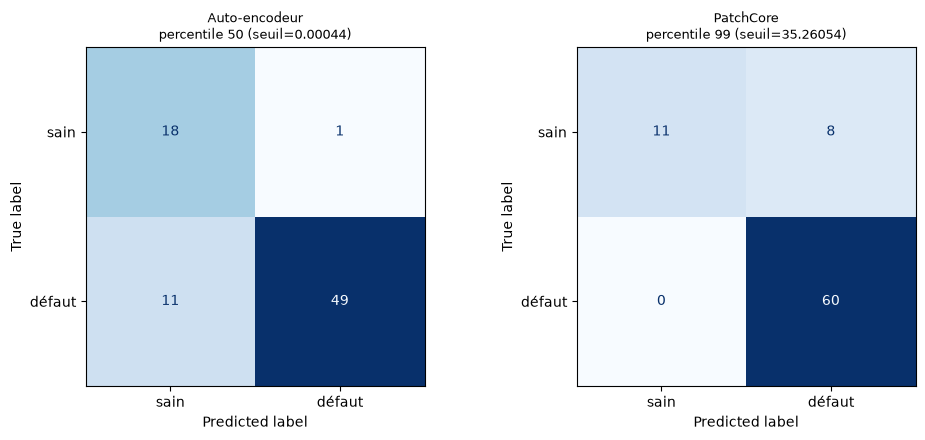

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, label, choice in [(axes[0], 'Auto-encodeur', ae_choice), (axes[1], 'PatchCore', pc_choice)]:
    confusion = np.array([
        [len(test_good_images) - choice['fp'], choice['fp']],
        [choice['fn'], (len(test_labels) - len(test_good_images)) - choice['fn']],
    ])
    ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=['sain', 'défaut']).plot(
        ax=ax, colorbar=False, cmap='Blues', values_format='d',
    )
    ax.set_title(f"{label}\n{choice['policy']} (seuil={choice['threshold']:.5f})", fontsize=9)
plt.tight_layout()

with mlflow.start_run(run_name='final-choice-comparison'):
    mlflow.log_metrics({
        'ae_chosen_recall': ae_choice['recall'], 'ae_chosen_precision': ae_choice['precision'],
        'ae_chosen_fa_rate_validation': ae_choice['fa_rate_validation'],
        'pc_chosen_recall': pc_choice['recall'], 'pc_chosen_precision': pc_choice['precision'],
        'pc_chosen_fa_rate_validation': pc_choice['fa_rate_validation'],
    })
    mlflow.log_figure(fig, 'confusion_matrices_final_choice.png')
plt.show()

## Décision finale et recommandation

**Modèle et seuil retenus pour la production : PatchCore, seuil calibré au 99ᵉ centile de la validation saine** (valeur mesurée ici : `35,26`, une distance interne au plus proche voisin, propre à ce modèle et à cette mémoire de patchs — à recalibrer si le modèle est ré-entraîné).

Ce choix découle directement de la décision métier : sur ce jeu de test, il atteint un rappel de 100 % (aucun défaut manqué) pour un taux de fausses alertes de 2,7 % sur la validation (8 fausses alertes sur 19 pièces saines de test) — largement préférable à l'auto-encodeur, qui plafonne à 81,7 % de rappel même au prix d'une fausse alerte sur une pièce saine sur deux.

**Limites à surveiller avant un déploiement réel** :
- Le test ne compte que 79 images (19 saines + 60 défauts) : un taux de fausses alertes de 2,7 % repose sur une seule fausse alerte de plus ou de moins pouvant le faire varier sensiblement — à reconfirmer sur un flux de production plus large avant de figer ce chiffre dans un contrat de service.
- La règle de choix (rappel maximal, puis fausses alertes minimales) ignore délibérément tout compromis de précision au-delà de ce qui est nécessaire pour atteindre ce rappel — cohérent avec la décision métier énoncée, mais à ne pas généraliser telle quelle à un contexte où le coût d'une fausse alerte serait significatif.
- Seule la catégorie `wood` est couverte ici ; `tp_deep_learning.ipynb` a montré que ce même choix de modèle (PatchCore vs auto-encodeur) est au moins aussi justifié, voire plus, sur `metal_nut`.

**Risques de production non couverts par ce notebook** (voir le cours « risques éthiques et robustesse »,
[fiche de révision](../../../docs/02-sprint-2/04-revisions/16-risques-biais-drift-robustesse-ethique-vision.md)) :
- **Biais** : le seuil `percentile 99` est calibré sur 37 images de validation saines, capturées dans les mêmes conditions (éclairage, cadrage) que l'entraînement ; sa validité sur des images de production réelles, potentiellement moins homogènes, n'est pas garantie et devrait être revérifiée avant mise en service.
- **Data drift / concept drift** : le seuil retenu (`35,26`) est figé à la date de calibration ; sans monitoring continu des scores de production ni politique de réentraînement périodique, une dérive progressive de la ligne (nouvelle caméra, usure, nouveau lot) ne serait détectée qu'après une remontée des défauts manqués.
- **Confidentialité/RGPD** : sans objet sur MVTec AD, mais à réévaluer sur des images de production réelles selon leur contenu.
- **Human-in-the-loop** : la politique retenue applique un seuil binaire unique (défaut/sain) ; le cours recommande une zone d'incertitude à vérification humaine pour les scores proches du seuil plutôt qu'une décision entièrement automatique, non mise en place ici.
- **Gouvernance et plan de repli** : ni la documentation formelle des cas exclus du périmètre (carte de modèle), ni le comportement du poste de contrôle en cas d'indisponibilité du modèle, ne sont définis dans ce notebook.

## Synthèse

Ce notebook a traduit une décision métier (« mieux vaut trop inspecter que manquer un défaut ») en un choix technique concret : parmi les deux modèles déjà comparés dans `tp_deep_learning.ipynb`, un balayage de 15 politiques de seuil calibrées uniquement sur la validation saine a montré que l'**auto-encodeur plafonne structurellement à 81,7 % de rappel** quel que soit le seuil choisi, alors que **PatchCore atteint 100 % de rappel** pour un coût de fausses alertes bien moindre (2,7 % contre plus de 50 % pour le meilleur rappel de l'auto-encodeur). La politique retenue (PatchCore, seuil au 99ᵉ centile de la validation) a été choisie par une règle fixée avant lecture des résultats de test, pour éviter tout biais de sélection a posteriori — une règle explicitement alignée sur la décision métier, dont les limites de généralisation (statistiques) et les risques de production (biais, drift, gouvernance) sont documentés ci-dessus plutôt que passés sous silence.